In [685]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [686]:
df = pd.read_csv('../Data/당뇨_전처리.csv')
df

,임신횟수,혈당,혈압,피부두께,인슐린,BMI,가족력지표,나이,당뇨
0,6,148.0,72.0,35.0,159.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,95.0,26.6,0.351,31,0
2,8,183.0,64.0,32.0,159.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
713,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
714,2,122.0,70.0,27.0,95.0,36.8,0.340,27,0
715,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
716,1,126.0,60.0,32.0,159.0,30.1,0.349,47,1


In [687]:
df = df[['BMI','혈당','나이','피부두께','가족력지표','당뇨']] #사용자가 입력할만한 feature들
# 피부 두께를 집에서 구하기 어렵다  피부두께 대신 당뇨 예측에 도움이 되는 파생변수를 생성해보자

## 사용자가 입력한 feature들로 파생변수를 만들어보자

#### BMI가 높아질수록 혈당이 올라가고 당뇨가 걸릴 확률이올라간다 



In [688]:
df = df[['BMI','혈당','나이','가족력지표','당뇨']]

---
로그를 씌워서 너무 데이터들이 너무 차이나지않게 했다

In [689]:
df['혈당_BMI'] = np.log1p(df['혈당'] * df['BMI'])
df['혈당_가족력'] = np.log1p(df['혈당'] * df['가족력지표'])


In [690]:
df = df[['BMI','혈당','나이','가족력지표','혈당_BMI','혈당_가족력','당뇨']]

In [691]:
df

,BMI,혈당,나이,가족력지표,혈당_BMI,혈당_가족력,당뇨
0,33.6,148.0,50,0.627,8.511939,4.541122,1
1,26.6,85.0,31,0.351,7.724005,3.428650,0
2,23.3,183.0,32,0.672,8.358174,4.820088,1
3,28.1,89.0,21,0.167,7.824806,2.763989,0
4,43.1,137.0,33,2.288,8.683673,5.750844,1
...,...,...,...,...,...,...,...
713,32.9,101.0,63,0.171,8.108894,2.905315,0
714,36.8,122.0,27,0.340,8.409742,3.749033,0
715,26.2,121.0,30,0.245,8.061865,3.422470,0
716,30.1,126.0,47,0.349,8.241071,3.806085,1


In [692]:
data = df.iloc[:,:-1]
target = df.iloc[:,-1]

train_data, test_data, train_target, test_target = train_test_split(
    data,
    target,
    random_state=42,
    test_size= 0.2,
    stratify=df.iloc[:,-1]
)

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_data)
train_scaled = ss.transform(train_data)
test_scaled = ss.transform(test_data)


In [693]:
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(574, 6)
(144, 6)
(574,)
(144,)


In [694]:
train_scaled.shape

(574, 6)

In [695]:
test_scaled.shape

(144, 6)

In [696]:
train_scaled

array([[ 1.68776653,  1.08208203,  0.26597507,  0.12437625,  1.63929716,
         0.78294796],
       [ 1.01130464,  0.22815126,  1.38035238, -0.39593703,  0.82405272,
        -0.0410719 ],
       [-1.11032584, -0.42083613, -0.93412357, -1.04710753, -0.88767982,
        -1.55743787],
       ...,
       [-0.23400021,  1.56028327,  1.38035238, -0.5423725 ,  0.91833526,
         0.13830198],
       [ 0.91905983,  0.91129588, -0.41979558, -0.44267175,  1.19505796,
         0.10724198],
       [ 1.51865105,  1.08208203,  0.43741773,  0.82851278,  1.56607445,
         1.30959349]])

In [697]:
test_scaled

array([[ 5.50080619e-01, -1.75296813e+00,  1.20890971e+00,
        -5.95338523e-01, -1.14298894e+00, -1.20101766e+00],
       [ 1.85688200e+00,  1.73106942e+00,  8.66024390e-01,
        -2.27692016e-01,  2.04476497e+00,  5.96963185e-01],
       [-2.87809679e-01, -4.51065872e-02, -1.01984490e+00,
         3.90988900e+00, -5.92996344e-02,  2.18374459e+00],
       [ 7.80692627e-01,  2.20927065e+00, -1.62631585e-01,
        -6.60767138e-01,  1.77940374e+00,  1.01695286e-01],
       [ 1.16504597e+00, -5.91622282e-01,  7.80303059e-01,
        -5.70413336e-01,  3.00710749e-01, -5.91759706e-01],
       [-5.72231156e-01, -7.62408437e-01, -9.34123566e-01,
        -1.03066082e-01, -7.90727540e-01, -7.41239064e-02],
       [-8.02843165e-01,  5.35566338e-01,  2.49472968e+00,
         6.57152118e-01, -1.31003196e-02,  1.03528957e+00],
       [-6.64475960e-01, -1.06982351e+00,  3.51696402e-01,
        -6.79461028e-01, -1.12576363e+00, -9.79603644e-01],
       [-4.49238085e-01, -6.94093975e-01, -7.691

In [698]:
x_train_data, x_valid_data, y_train_target, y_valid_target = train_test_split(
    train_scaled,
    train_target,
    random_state=42,
    test_size= 0.2,
    stratify=train_target
)

In [699]:
train_scaled

array([[ 1.68776653,  1.08208203,  0.26597507,  0.12437625,  1.63929716,
         0.78294796],
       [ 1.01130464,  0.22815126,  1.38035238, -0.39593703,  0.82405272,
        -0.0410719 ],
       [-1.11032584, -0.42083613, -0.93412357, -1.04710753, -0.88767982,
        -1.55743787],
       ...,
       [-0.23400021,  1.56028327,  1.38035238, -0.5423725 ,  0.91833526,
         0.13830198],
       [ 0.91905983,  0.91129588, -0.41979558, -0.44267175,  1.19505796,
         0.10724198],
       [ 1.51865105,  1.08208203,  0.43741773,  0.82851278,  1.56607445,
         1.30959349]])

In [700]:
depth_list = range(1, 31)  # 깊이 1 ~ 30
dt_cross_val_scores = []

for depth in depth_list:
    dt = DecisionTreeClassifier(
        max_depth=depth,
         ccp_alpha=0.01,#가지치기 강도”를 조절하는 하이퍼파라미터
        random_state=42
    )

    scores = cross_val_score(
        dt,
        x_train_data,
        y_train_target,
        cv=6,                  # 6-fold CV
        scoring='accuracy',
        n_jobs=-1
    )

    dt_cross_val_scores.append(scores.mean())

best_depth = depth_list[dt_cross_val_scores.index(max(dt_cross_val_scores))]
best_depth

3

In [701]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
     ccp_alpha=0.01,#가지치기 강도”를 조절하는 하이퍼파라미터
    random_state=42
).fit(x_train_data, y_train_target)
xdtTrain = []
xdtValid = []
for i in range(5):
    xdtTrain.append(dt.score(x_train_data, y_train_target))
    xdtValid.append(dt.score(x_valid_data, y_valid_target))
    print(dt.score(x_train_data, y_train_target))
    print(dt.score(x_valid_data, y_valid_target))

0.803921568627451
0.7478260869565218
0.803921568627451
0.7478260869565218
0.803921568627451
0.7478260869565218
0.803921568627451
0.7478260869565218
0.803921568627451
0.7478260869565218


In [702]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    x_train_data, y_train_target
)

ccp_alphas = path.ccp_alphas

In [703]:
train_scores = []
valid_scores = []

for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha#가지치기 강도”를 조절하는 하이퍼파라미터
    )
    dt.fit(x_train_data, y_train_target)
    
    train_scores.append(dt.score(x_train_data, y_train_target))
    valid_scores.append(dt.score(x_valid_data, y_valid_target))

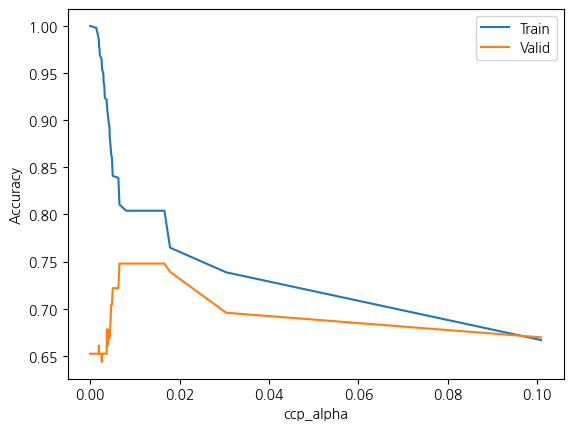

In [704]:
import matplotlib.pyplot as plt

plt.plot(ccp_alphas, train_scores, label='Train')
plt.plot(ccp_alphas, valid_scores, label='Valid')
plt.legend()
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.show()

In [705]:
print('xTrain : ',np.mean(xdtTrain))
print('Valid : ',np.mean(xdtValid))


xTrain :  0.803921568627451
Valid :  0.7478260869565218


In [706]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
     ccp_alpha=0.01,#가지치기 강도”를 조절하는 하이퍼파라미터
    random_state=42
).fit(train_scaled, train_target)
dtTest = []
dtTrain = []
for i in range(5):
    dtTrain.append(dt.score(train_scaled, train_target))
    dtTest.append(dt.score(test_scaled, test_target))
    print(dt.score(train_scaled, train_target))
    print(dt.score(test_scaled, test_target))

0.794425087108014
0.75
0.794425087108014
0.75
0.794425087108014
0.75
0.794425087108014
0.75
0.794425087108014
0.75


## 차이가 0.05보다 작긴하지만 0.80을 못넘어 쓰지는 못할거같다

In [707]:
print('Train : ',np.mean(dtTrain))
print('Test : ',np.mean(dtTest))


Train :  0.794425087108014
Test :  0.75


In [708]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [709]:
pred=dt.predict(test_scaled)
conf_matrix =confusion_matrix(test_target,pred)

conf_matrix

array([[78, 18],
       [18, 30]], dtype=int64)

In [710]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

# 예측
pred = dt.predict(test_scaled)

#  기본 지표들
acc = accuracy_score(test_target, pred)
prec = precision_score(test_target, pred)  
rec = recall_score(test_target, pred)       
f1 = f1_score(test_target, pred)

print("\n[추가 평가 지표]")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")



#  분류 리포트 (클래스별 precision/recall/f1)
print("\n[Classification Report]")
print(classification_report(test_target, pred, digits=4))


[추가 평가 지표]
Accuracy  : 0.7500
Precision : 0.6250
Recall    : 0.6250
F1-score  : 0.6250

[Classification Report]
              precision    recall  f1-score   support

           0     0.8125    0.8125    0.8125        96
           1     0.6250    0.6250    0.6250        48

    accuracy                         0.7500       144
   macro avg     0.7188    0.7188    0.7188       144
weighted avg     0.7500    0.7500    0.7500       144



### 

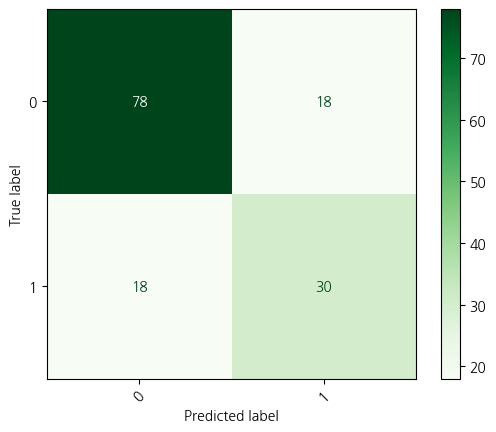

In [711]:
disp =ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=sorted(test_target.unique())
)

disp.plot(
    cmap=plt.cm.Greens,
    xticks_rotation=45
)
plt.show()

원래 feature들을  다넣으면 좋은 예측력이 나오긴하지만 앱으로 만들때는 사용자가 입력할수 없는것도 있기때문에 사용자가 입력할수있는것만 넣었서 진행했지만  Train과 Test 예측력이 차이나서 과소적합이 발생했다 그래서 사용자가 입력한것중에 파생변수로 만들어 예측력을 높이는 시도를 해보았지만 
예측력이 75로 비슷하게 나와 의사결정 나무는 이 데이터를 예측하기엔 좋은모델은 아닌거 같다 

Decision Tree는 해석력은 좋지만, 현재 데이터 규모에서는 과적합이 반복적으로 발생했습니다.       
가지치기와 파생변수 조정을 시도했으나 일반화 성능이 안정적으로 개선되지 않았습니다.     
따라서 단일 트리 대신 분산을 줄일 수 있는 앙상블 모델(Random Forest 등)로 전환하는 것이 합리적일것 같다        